# 03 Encoder, generativni prompt model i fine-tuning

Ovaj notebook je prezentacioni pregled naprednih NLP eksperimenata nad Turismy recenzijama. Prikazuje rezultate za:

- encoder klasifikaciju pomocu `sentence-transformers/all-MiniLM-L6-v2`
- generativnu klasifikaciju pomocu promptova i modela `Qwen/Qwen3-4B-Instruct-2507`
- fine-tuning malog BERT modela `prajjwal1/bert-tiny`
- poredjenje sa najboljim klasicnim TF-IDF modelom
- primere gresaka i generativnih izlaza

Notebook cita vec generisane metrike iz `artifacts/metrics/`, tako da ga je moguce otvoriti i pokazati bez cekanja na ponovno treniranje.

In [1]:
from pathlib import Path
import sys

_PROJECT_MARKERS = (
    Path('src') / 'data' / 'prepare_dataset.py',
    Path('Turismy') / 'reviews.csv',
)


def _is_project_root(path):
    return all((path / marker).exists() for marker in _PROJECT_MARKERS)


def _candidate_roots(start):
    start = start.resolve()
    seen = set()

    for candidate in (start, *start.parents):
        if candidate not in seen:
            seen.add(candidate)
            yield candidate

    for base in (start, start.parent):
        try:
            children = list(base.iterdir())
        except OSError:
            continue

        for child in children:
            try:
                if not child.is_dir():
                    continue
                candidate = child.resolve()
            except OSError:
                continue

            if candidate not in seen:
                seen.add(candidate)
                yield candidate


def find_project_root():
    for candidate in _candidate_roots(Path.cwd()):
        if _is_project_root(candidate):
            return candidate

    raise RuntimeError('Project root was not found.')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/Users/mina/git_repos/MasinskoUcenje-Projekat')

In [2]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid')

metrics_dir = PROJECT_ROOT / 'artifacts' / 'metrics'
figures_dir = PROJECT_ROOT / 'artifacts' / 'figures'


def load_json(name):
    path = metrics_dir / name
    if not path.exists():
        raise FileNotFoundError(
            f'Missing {path}. Run: .venv311/bin/python -m src.pipeline.run_all '
            '--encoder-sample-size 500 --prompt-sample-size 500 --finetune-sample-size 500'
        )
    return json.loads(path.read_text(encoding='utf-8'))

classification_metrics = load_json('classification_metrics.json')
encoder_metrics = load_json('encoder_metrics.json')
prompt_metrics = load_json('prompt_metrics.json')
finetuning_metrics = load_json('finetuning_metrics.json')
regression_metrics = load_json('regression_metrics.json')
error_analysis = load_json('error_analysis.json')

loaded = pd.DataFrame(
    [
        {'artifact': 'classification_metrics.json', 'purpose': 'Klasicni TF-IDF klasifikatori'},
        {'artifact': 'encoder_metrics.json', 'purpose': 'Encoder klasifikacija'},
        {'artifact': 'prompt_metrics.json', 'purpose': 'Generativna prompt klasifikacija'},
        {'artifact': 'finetuning_metrics.json', 'purpose': 'BERT-tiny fine-tuning'},
        {'artifact': 'regression_metrics.json', 'purpose': 'Klasicni regresioni modeli'},
        {'artifact': 'error_analysis.json', 'purpose': 'Analiza gresaka'},
    ]
)
display(loaded)

,artifact,purpose
0,classification_metrics.json,Klasicni TF-IDF klasifikatori
1,encoder_metrics.json,Encoder klasifikacija
2,prompt_metrics.json,Generativna prompt klasifikacija
3,finetuning_metrics.json,BERT-tiny fine-tuning
4,regression_metrics.json,Klasicni regresioni modeli
5,error_analysis.json,Analiza gresaka


## Zasto je generativni model ranije vracao samo `0` i zasto je izabran Qwen?

Prvobitni prompt je trazio od `google/flan-t5-small` da odjednom vrati ceo JSON za cetiri labele. Taj model je veoma mali i kod ovakvog prompta cesto zadatak svede na jedan binarni odgovor, pa vrati samo `0` ili `1` umesto strukture sa labelama.

Finalni generativni eksperiment je zato prebacen na stabilniji i jaci pristup:

1. koristi se `Qwen/Qwen3-4B-Instruct-2507`, lokalni instruction model od oko 4B parametara
2. model se pita posebno za svaku labelu
3. odgovor je jednostavan `yes`/`no`
4. svaki odgovor se parsira u `1` ili `0`

Qwen3 4B je izabran kao najbolji prakticni kandidat za MacBook sa 16 GB RAM-a u ovom projektu. Jaci je od FLAN-T5 i nije gated na Hugging Face-u. Llama 3.2 3B i Gemma 3 4B su dobri modeli, ali su gated i traze prihvacen HF pristup/token. Llama/Gemma 7B ili 8B modeli mogu biti bolji, ali su za 16 GB RAM-a realnije opcije tek kroz quantized/GGUF pokretanje, sto bi uvelo drugi inference stack.

In [3]:
rows = []

best_classic_name = classification_metrics['best_model']
best_classic = classification_metrics['models'][best_classic_name]
rows.append(
    {
        'approach': f'Classic TF-IDF ({best_classic_name})',
        'model': best_classic_name,
        'sample_size': 'full test split',
        'micro_precision': best_classic['micro_precision'],
        'micro_recall': best_classic['micro_recall'],
        'micro_f1': best_classic['micro_f1'],
        'macro_f1': best_classic['macro_f1'],
        'subset_accuracy': best_classic['subset_accuracy'],
    }
)

for label, payload in [
    ('Encoder embeddings', encoder_metrics),
    ('Prompt generative', prompt_metrics),
    ('Fine-tuned BERT-tiny', finetuning_metrics),
]:
    rows.append(
        {
            'approach': label,
            'model': payload.get('model'),
            'sample_size': payload.get('sample_size'),
            'micro_precision': payload.get('micro_precision'),
            'micro_recall': payload.get('micro_recall'),
            'micro_f1': payload.get('micro_f1'),
            'macro_f1': payload.get('macro_f1'),
            'subset_accuracy': payload.get('subset_accuracy'),
        }
    )

summary = pd.DataFrame(rows)
summary_display = summary.copy()
for column in ['micro_precision', 'micro_recall', 'micro_f1', 'macro_f1', 'subset_accuracy']:
    summary_display[column] = summary_display[column].map(lambda value: f'{value:.4f}')

display(Markdown('## Ukupno poredjenje klasifikacionih pristupa'))
display(summary_display)

## Ukupno poredjenje klasifikacionih pristupa

,approach,model,sample_size,micro_precision,micro_recall,micro_f1,macro_f1,subset_accuracy
0,Classic TF-IDF (linear_svm),linear_svm,full test split,0.8734,0.8504,0.8618,0.7973,0.7265
1,Encoder embeddings,sentence-transformers/all-MiniLM-L6-v2,500,0.6000,0.7377,0.6618,0.5809,0.3600
2,Prompt generative,Qwen/Qwen3-4B-Instruct-2507,500,0.6898,0.8157,0.7475,0.6612,0.4840
3,Fine-tuned BERT-tiny,prajjwal1/bert-tiny,500,0.6083,0.4966,0.5468,0.1881,0.2560


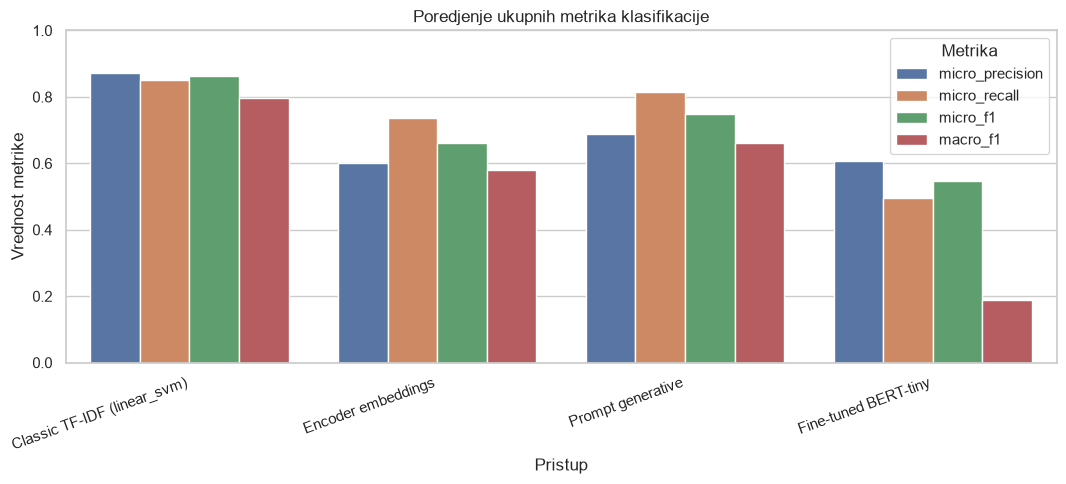

In [4]:
plot_data = summary.melt(
    id_vars=['approach'],
    value_vars=['micro_precision', 'micro_recall', 'micro_f1', 'macro_f1'],
    var_name='metric',
    value_name='score',
)

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_data, x='approach', y='score', hue='metric')
plt.ylim(0, 1)
plt.title('Poredjenje ukupnih metrika klasifikacije')
plt.xlabel('Pristup')
plt.ylabel('Vrednost metrike')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Metrika', loc='upper right')
plt.tight_layout()
plt.show()

## Per-label metrike

Kod multi-label klasifikacije nije dovoljno gledati samo ukupni F1. Vazno je proveriti kako se model ponasa po svakoj oznaci, posebno zato sto je `family_friendly` nebalansirana labela sa mnogo manje pozitivnih primera.

,approach,label,precision,recall,f1,support
0,Classic TF-IDF (linear_svm),cleanliness,0.9456,0.8845,0.9141,511.0
1,Classic TF-IDF (linear_svm),location,0.9028,0.8846,0.8936,1187.0
2,Classic TF-IDF (linear_svm),luxury,0.7851,0.7906,0.7878,573.0
3,Classic TF-IDF (linear_svm),family_friendly,0.6301,0.5610,0.5935,82.0
4,Encoder embeddings,cleanliness,0.5000,0.7692,0.6061,26.0
5,Encoder embeddings,location,0.7288,0.7414,0.7350,58.0
6,Encoder embeddings,luxury,0.5556,0.7812,0.6494,32.0
7,Encoder embeddings,family_friendly,0.3333,0.3333,0.3333,6.0
8,Prompt generative,cleanliness,0.8849,0.9179,0.9011,134.0
9,Prompt generative,location,0.7613,0.9863,0.8593,291.0


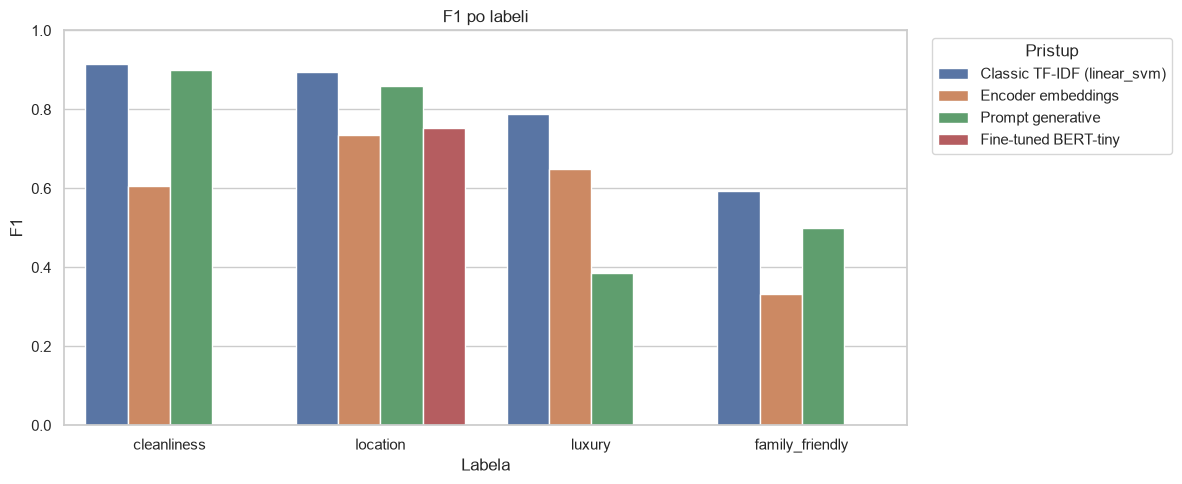

In [5]:
def per_label_frame(name, payload):
    frame = pd.DataFrame(payload['per_label']).T.reset_index().rename(columns={'index': 'label'})
    frame.insert(0, 'approach', name)
    return frame

per_label = pd.concat(
    [
        per_label_frame(f'Classic TF-IDF ({best_classic_name})', best_classic),
        per_label_frame('Encoder embeddings', encoder_metrics),
        per_label_frame('Prompt generative', prompt_metrics),
        per_label_frame('Fine-tuned BERT-tiny', finetuning_metrics),
    ],
    ignore_index=True,
)

display(per_label.round(4))

plt.figure(figsize=(12, 5))
sns.barplot(data=per_label, x='label', y='f1', hue='approach')
plt.ylim(0, 1)
plt.title('F1 po labeli')
plt.xlabel('Labela')
plt.ylabel('F1')
plt.legend(title='Pristup', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Primeri generativnog prompt modela

Tabela ispod prikazuje stvarne komentare, sirove `yes`/`no` odgovore modela `Qwen/Qwen3-4B-Instruct-2507` za svaku labelu i parsirane vrednosti `0/1`. Ovo je korisno za seminarski rad jer pokazuje kako se generativni tekstualni izlaz pretvara u klasifikacione labele.

In [6]:
prompt_examples = []
for index, example in enumerate(prompt_metrics.get('examples', [])[:8], start=1):
    raw_outputs = example.get('raw_outputs', {})
    parsed = example.get('parsed', {})
    prompt_examples.append(
        {
            'example': index,
            'comment': example['comment'][:180] + ('...' if len(example['comment']) > 180 else ''),
            'raw cleanliness': raw_outputs.get('cleanliness'),
            'raw location': raw_outputs.get('location'),
            'raw luxury': raw_outputs.get('luxury'),
            'raw family': raw_outputs.get('family_friendly'),
            'parsed cleanliness': parsed.get('cleanliness'),
            'parsed location': parsed.get('location'),
            'parsed luxury': parsed.get('luxury'),
            'parsed family': parsed.get('family_friendly'),
        }
    )

display(pd.DataFrame(prompt_examples))

,example,comment,raw cleanliness,raw location,raw luxury,raw family,parsed cleanliness,parsed location,parsed luxury,parsed family
0,1,Fantastic weekend in Amsterdam! The boat is co...,no,yes,yes,no,0,1,1,0
1,2,The place is lovely! very unique and cozy! Sha...,no,no,yes,yes,0,0,1,1
2,3,Perfect location; quiet but lived in. Boat is ...,no,yes,no,no,0,1,0,0
3,4,"Diewert is a fine gentleman, and a very accomm...",no,no,no,no,0,0,0,0
4,5,"convenient location, easy to get everywhere an...",no,yes,no,no,0,1,0,0
5,6,This houseboat is the perfect place to stay in...,no,yes,no,no,0,1,0,0
6,7,Alex was welcoming and helpful. The room was j...,no,yes,no,no,0,1,0,0
7,8,edwin是一个非常幽默的人，同时他也很热情，很周到。提供的房间不大，但是很温馨，很好，非常喜欢,no,no,no,no,0,0,0,0


## Regresione metrike

Regresioni deo predvidja sinteticku decimalnu ocenu `visitor_rating`. Za regresiju koristimo MAE, RMSE i R2, a ne precision/recall/F1.

,model,mae,rmse,r2,is_best
0,ridge,0.2019,0.2514,0.6316,False
1,linear_regression,0.7757,1.2220,-7.7072,False
2,random_forest,0.1993,0.2533,0.6260,True


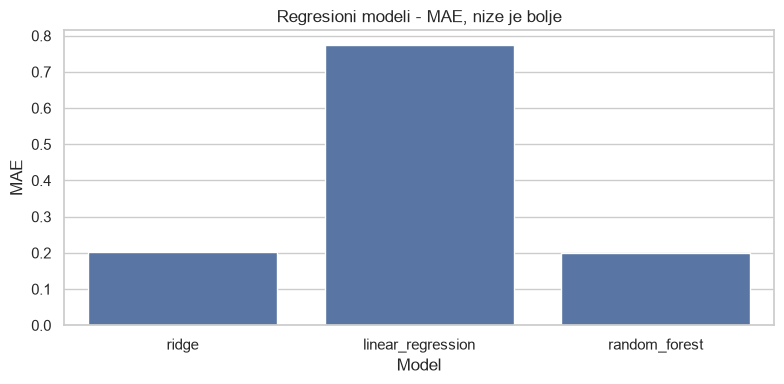

In [7]:
regression_rows = []
for model_name, metrics in regression_metrics['models'].items():
    regression_rows.append(
        {
            'model': model_name,
            'mae': metrics['mae'],
            'rmse': metrics['rmse'],
            'r2': metrics['r2'],
            'is_best': model_name == regression_metrics['best_model'],
        }
    )

regression_table = pd.DataFrame(regression_rows)
display(regression_table.round(4))

plt.figure(figsize=(8, 4))
sns.barplot(data=regression_table, x='model', y='mae')
plt.title('Regresioni modeli - MAE, nize je bolje')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

## Analiza gresaka klasifikacije

Sledeci primeri prikazuju gde najbolji klasicni klasifikator pravi false positive i false negative greske. Ovi primeri su pogodni za kvalitativnu analizu u seminarskom radu.

In [8]:
error_rows = []
for label, payload in error_analysis.get('classification', {}).items():
    for error_type in ['false_positives', 'false_negatives']:
        for example in payload.get(error_type, [])[:2]:
            error_rows.append(
                {
                    'label': label,
                    'error_type': error_type,
                    'comment': example['comment'][:220] + ('...' if len(example['comment']) > 220 else ''),
                    'true': example['true'],
                    'predicted': example['predicted'],
                }
            )

display(pd.DataFrame(error_rows))

,label,error_type,comment,true,predicted
0,cleanliness,false_positives,Хорошая квартира все как на фото! Есть все удо...,0,1
1,cleanliness,false_positives,Daniel was the perfect host. Very helpful with...,0,1
2,cleanliness,false_negatives,This houseboat is the perfect place to stay in...,1,0
3,cleanliness,false_negatives,Die Beschreibungen sowohl bei der Buchungsbest...,1,0
4,location,false_positives,Fantastic weekend in Amsterdam! The boat is co...,0,1
5,location,false_positives,Wonderful location and welcoming people,0,1
6,location,false_negatives,Actually more than we expected. Great neighbor...,1,0
7,location,false_negatives,"Quartier idéal pour tout faire à pieds, 10mn d...",1,0
8,luxury,false_positives,This houseboat is the perfect place to stay in...,0,1
9,luxury,false_positives,Die Unterkunft ist wirklich etwas besonderes. ...,0,1


## Najvece regresione greske

Ovi komentari imaju najvece apsolutne greske izmedju stvarne sinteticke ocene i predikcije regresionog modela.

In [9]:
reg_error_rows = []
for example in error_analysis.get('regression', {}).get('largest_absolute_errors', [])[:10]:
    reg_error_rows.append(
        {
            'comment': example['comment'][:220] + ('...' if len(example['comment']) > 220 else ''),
            'true': example['true'],
            'predicted': example['predicted'],
            'absolute_error': example['absolute_error'],
        }
    )

display(pd.DataFrame(reg_error_rows))

,comment,true,predicted,absolute_error
0,Great place to stay. We stayed with five peopl...,4.7,3.5376,1.1624
1,This apartment was perfect for our group of fi...,4.8,3.6973,1.1027
2,Das wunderschöne Appartment liegt nur wenige G...,4.5,3.4549,1.0451
3,We had an exceptional stay with Joanna and MP....,4.9,3.8958,1.0042
4,We had a lovely stay in this beautiful apartme...,4.8,3.8709,0.9291
5,I am staying more than 200 nights per year out...,3.5,4.3997,0.8997
6,Can't say enough about how wonderful of a host...,4.3,3.4302,0.8698
7,Booking was easy with Daan. I texted him once ...,4.6,3.7369,0.8631
8,Edwin was a great host with good communication...,2.9,3.7363,0.8363
9,Lovely spot with a great sized room with a bal...,4.3,3.4805,0.8195


## Zakljucak za prezentaciju

- Najbolji ukupni rezultat daje klasicni `TF-IDF + Linear SVM`. To je ocekivano jer dataset ima jasne tekstualne signale i relativno malo labela.
- Encoder `all-MiniLM-L6-v2` daje semanticke embeddinge, ali je u ovom run-u treniran na manjem uzorku, pa je slabiji od punog TF-IDF modela.
- Generativni `Qwen/Qwen3-4B-Instruct-2507` pokazuje kako se veci instruction model moze koristiti za klasifikaciju bez treniranja. Bolji je od FLAN-T5 prompta, ali je i dalje sporiji i osetljiviji na formulaciju prompta od klasicnog modela.
- Fine-tuned `bert-tiny` pokazuje tok prilagodjavanja transformer modela na konkretan zadatak, ali zbog CPU-friendly malog uzorka ne mora da pobedi klasicni model.
- `family_friendly` je najteza labela zato sto ima najmanje pozitivnih primera.

## Opcioni rerun eksperimenata

Sledece celije nisu potrebne za prezentaciju. Koriste se samo ako zelis ponovo da generises artefakte. Podrazumevano su iskljucene da se notebook brzo otvara i izvrsava.

In [10]:
RUN_FULL_EXPERIMENTS = False

if RUN_FULL_EXPERIMENTS:
    from src.pipeline.run_all import run_all

    run_all(
        encoder_sample_size=500,
        prompt_sample_size=500,
        finetune_sample_size=500,
        skip_prompt=False,
        skip_finetuning=False,
    )
    print('Pipeline finished. Re-run the metric loading cells above to refresh tables.')
else:
    print('RUN_FULL_EXPERIMENTS is False. Existing artifacts are displayed above.')

RUN_FULL_EXPERIMENTS is False. Existing artifacts are displayed above.
